# **Comenzaremos con el proyecto de machine learning**

**- Lo primero que haremos sera convertir nuestro archivo de texro BAdiraguato, a csv para un mejor analisis**

In [1]:
import pandas as pd

**Al ya haber utilizado este archivo de texto en otra ocasion, ya tenemos la manera correcta de limpiar el archivo de texto**

In [3]:
df = pd.read_csv(
    'BAdiraguato.txt', #Nombre del archivo
    sep=r"\s+", #Separado mediante espacios 
    engine="python", #Motor de análisis
    encoding="cp1250", #Codificación del archivo
    skiprows=17, #Saltar "metadatos"
    header=None, #No hay encabezado en el archivo
    names = ["FECHA", "PRECIP (MM)", 'EVAP (MM)', 'TMAX (°C)', 'TMIN (°C)'] #Nombres de las columnas
    )

#Eliminamos las dos primeras columnas ya que son los encabezados originales del txt
df = df.iloc[2:].reset_index(drop=True)

df.to_csv("BAdiraguato.csv", index=False) #Mediante este comando se guarda el DataFrame en un nuevo archivo CSV
df.head()

,FECHA,PRECIP (MM),EVAP (MM),TMAX (°C),TMIN (°C)
0,01/01/1960,0,Nulo,Nulo,Nulo
1,02/01/1960,0,Nulo,Nulo,Nulo
2,03/01/1960,6,Nulo,Nulo,Nulo
3,04/01/1960,30,Nulo,Nulo,Nulo
4,05/01/1960,0,Nulo,Nulo,Nulo


**Para comenzar a trabajar, importaremos el resto de librerias a utilizar**

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Ahora veremos las filas y columnas del dataset**

In [6]:
df.shape

(19184, 5)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19184 entries, 0 to 19183
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   FECHA        19184 non-null  str  
 1   PRECIP (MM)  19183 non-null  str  
 2   EVAP (MM)    19183 non-null  str  
 3   TMAX (°C)    19183 non-null  str  
 4   TMIN (°C)    19183 non-null  str  
dtypes: str(5)
memory usage: 749.5 KB


In [12]:
df.dtypes

FECHA          str
PRECIP (MM)    str
EVAP (MM)      str
TMAX (°C)      str
TMIN (°C)      str
dtype: object

**podemos observar que todas los datos se encuentran en string por lo que debemos de cambiarlos hacia tipos de datos numericos**

**Lo primero que haremos sera eliminar todos los "Nulos" y convertirlos en NaN**

In [16]:
# Para remplazar los nulos
df = df.replace("Nulo", np.nan)

# Para convertir las columnas a numéricas
for col in ['PRECIP (MM)', 'EVAP (MM)', 'TMAX (°C)', 'TMIN (°C)']:
    df[col] = pd.to_numeric(df[col], errors='coerce')   #Agregamos el error, para que siga avanzando aunque haya valores no numéricos

df.head()

,FECHA,PRECIP (MM),EVAP (MM),TMAX (°C),TMIN (°C)
0,01/01/1960,0.0,NaN,NaN,NaN
1,02/01/1960,0.0,NaN,NaN,NaN
2,03/01/1960,6.0,NaN,NaN,NaN
3,04/01/1960,30.0,NaN,NaN,NaN
4,05/01/1960,0.0,NaN,NaN,NaN


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19184 entries, 0 to 19183
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   FECHA        19184 non-null  str    
 1   PRECIP (MM)  19138 non-null  float64
 2   EVAP (MM)    9777 non-null   float64
 3   TMAX (°C)    18794 non-null  float64
 4   TMIN (°C)    18792 non-null  float64
dtypes: float64(4), str(1)
memory usage: 749.5 KB


In [18]:
df.dtypes

FECHA              str
PRECIP (MM)    float64
EVAP (MM)      float64
TMAX (°C)      float64
TMIN (°C)      float64
dtype: object

**Ahora que ya tenemos los datos necesarios para poder proseguir, continuaremos con el analisis**

In [20]:
# Contaremos las variables faltantes por cada variable
cols = ["PRECIP (MM)", "EVAP (MM)", "TMAX (°C)", "TMIN (°C)"]

resumen = pd.DataFrame({
    "faltantes": df[cols].isna().sum()
})

print(resumen)

             faltantes
PRECIP (MM)         46
EVAP (MM)         9407
TMAX (°C)          390
TMIN (°C)          392


In [26]:

#Primero convertiremos la fecha a formato de fecha
df["FECHA"] = pd.to_datetime(df["FECHA"], dayfirst=True, errors="coerce")

#Despues calcularemos cuantos datos faltan por año
faltantesporaño = df.isna().groupby(df["FECHA"].dt.year).sum()
print(faltantesporaño)

        FECHA  PRECIP (MM)  EVAP (MM)  TMAX (°C)  TMIN (°C)
FECHA                                                      
1960.0      0            0        330        330        330
1961.0      0            0        364          0          0
1962.0      0            0        365          0          0
1963.0      0            0        365          3          3
1964.0      0            1        366          0          0
1965.0      0            0         98          1          1
1966.0      0            0          3          0          1
1967.0      0            0          2          0          0
1968.0      0            0          5          0          0
1969.0      0           30          0          0          0
1970.0      0            0          0          0          0
1971.0      0            0          1          0          0
1972.0      0            0          0          0          0
1973.0      0            0          1          0          0
1974.0      0            0          0   

# **Ahora que conocemos los datos mas a fondo, comencemos con la graficacion para hacer un analisis visual**

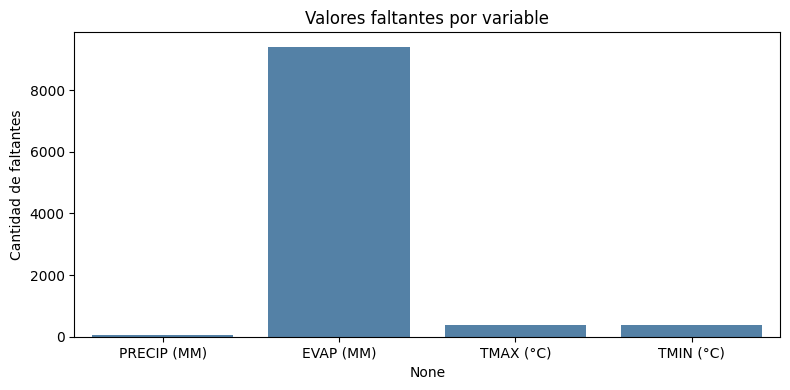

In [53]:
cols = ["PRECIP (MM)", "EVAP (MM)", "TMAX (°C)", "TMIN (°C)"]

faltantes = df[cols].isna().sum()
plt.figure(figsize=(8,4))
sns.barplot(x=faltantes.index, y=faltantes.values, color="steelblue")
plt.ylabel("Cantidad de faltantes")
plt.title("Valores faltantes por variable")
plt.tight_layout()
plt.show()

**Como podemos observar la variabe de evaporacion es la que cuenta con mas valores nulos**

**Esto nos reduce la cantidad de informacion util de manera considerable, ya que pueden existir sesgos en promedios o estadisticas y con lo que sera un tanto dificil entrenar un modelo de machine learning ya que si se eliminan muchas filas, perderemos mucha informacion**

# **Utilizaremos la metodologia Random Forest Regressor**

**Utilizaremos esta metodologia ya que puede capturar relaciones no lineales entre variables y tambien sirve cuando las variables dependen unas de otras**

 # **En comparacion con otras**

**Regresión lineal: es mas simple, pero funciona mejor cuando la relacionn entre variables es casi lineal**

**KNN: usa valores de registros parecidos, pero puede ser sensible si hay escalas diferentes o muchos faltantes**

# Ahora ajustaremos los datos del modelo para usarlos como base

In [28]:
datos_modelo = df[cols].copy()

In [29]:
datos_modelo.head()

,PRECIP (MM),EVAP (MM),TMAX (°C),TMIN (°C)
0,0.0,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN
2,6.0,NaN,NaN,NaN
3,30.0,NaN,NaN,NaN
4,0.0,NaN,NaN,NaN


**Al ya tener la copia creada, separaremos los datos para quedarnos solo con filas que tienen los datos completos**

In [31]:
datos_completos = datos_modelo.dropna()
print(datos_completos.shape)
datos_completos.head()

(9692, 4)


,PRECIP (MM),EVAP (MM),TMAX (°C),TMIN (°C)
597,0.0,2.0,38.0,23.0
1886,0.0,8.3,33.0,9.0
1887,0.0,6.7,33.5,10.5
1888,0.0,5.9,35.0,12.0
1889,0.0,3.1,30.5,13.5


**Esto se hace con la intencion de que el modelo quede con la menor variacion de datos, ya que al dejar NaN el modelo no entrenaria de la manera correcta**

In [ ]:
# Librerias de ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Primero estimaremos Evap

In [79]:
datos_evap = datos_completos[["PRECIP (MM)", "TMAX (°C)", "TMIN (°C)", "EVAP (MM)"]].copy()




Se usan tres variables como entradas:
precipitacion, temperatura maxima, temperatura minima

Y como salida se usa: evaporacion

In [80]:
X = datos_evap[["PRECIP (MM)", "TMAX (°C)", "TMIN (°C)"]]
y = datos_evap["EVAP (MM)"]

separamos entrada como x y salida como y

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Utilizamos 80% de los datos para entrenamiento y 20% de los datos para prueba
#test size = 0.2 quiere decir que usara el 20% de los datos para prueba
#random state = 42 es para asegurar que siempre obtengamos la misma operacion de los datos, sin importar cuantas veces ejecutemos el codigo

In [82]:
modelo = RandomForestRegressor(n_estimators=100, random_state=42)
# Usaremos 100 arboles y el mismo random state para reproducibilidad

In [83]:
modelo.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [84]:
pred = modelo.predict(X_test)

In [85]:
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

In [86]:
print("Error cuadratico medio (MSE) = ", mse)
print('Coeficiente de determinacion (R2)= ', r2)

Error cuadratico medio (MSE) =  3.4873915209578583
Coeficiente de determinacion (R2)=  0.4852850293362805


Que quiere decir esto que acabamos de observar:
el mse es de 3.49 redondeando lo que quiere decir que las predicciones se alejan del valor real, aunque no por demasiado
el r2 es de 0.49 lo que quiere decir que el modelo explica el 49% de la variacion

**Si bien no son unas predicciones perfectas, son unas predicciones utiles para la base de imputacion faltantes**

# **Lo que realizaremos a continuacion:**
**Usaremos el modelo entrenado para llenar los valores faltantes dentro de la evaporacion**

In [87]:
# Entrenar el modelo con los datos completos
X_evap = datos_completos[["PRECIP (MM)", "TMAX (°C)", "TMIN (°C)"]]
y_evap = datos_completos["EVAP (MM)"]

modelo_evap = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_evap.fit(X_evap, y_evap)

# Crear una copia para guardar el resultado final
resultado = datos_modelo.copy()

# Buscar filas donde EVAP está vacío pero las otras variables si tienen datos
mask_evap = resultado["EVAP (MM)"].isna() & resultado[["PRECIP (MM)", "TMAX (°C)", "TMIN (°C)"]].notna().all(axis=1)

# Imputar los valores faltantes
resultado.loc[mask_evap, "EVAP (MM)"] = modelo_evap.predict(
    resultado.loc[mask_evap, ["PRECIP (MM)", "TMAX (°C)", "TMIN (°C)"]]
)

resultado.head()

,PRECIP (MM),EVAP (MM),TMAX (°C),TMIN (°C)
0,0.0,NaN,NaN,NaN
1,0.0,NaN,NaN,NaN
2,6.0,NaN,NaN,NaN
3,30.0,NaN,NaN,NaN
4,0.0,NaN,NaN,NaN


**Podria parecer que es un error, pero lo que hicimos fue inputar valores, solo donde existian valores en el resto de las variables**

In [88]:
antes = datos_modelo["EVAP (MM)"].isna().sum()
despues = resultado["EVAP (MM)"].isna().sum()

print("Faltantes en EVAP antes:", antes)
print("Faltantes en EVAP después:", despues)

Faltantes en EVAP antes: 9407
Faltantes en EVAP después: 353


Como observamos, es una cantidad muy menor de faltantes

In [89]:
print("Faltantes restantes por variable:")
print(resultado.isna().sum())

Faltantes restantes por variable:
PRECIP (MM)     46
EVAP (MM)      353
TMAX (°C)      390
TMIN (°C)      392
dtype: int64


In [92]:
resultado[mask_evap][["PRECIP (MM)", "EVAP (MM)", "TMAX (°C)", "TMIN (°C)"]].head()

,PRECIP (MM),EVAP (MM),TMAX (°C),TMIN (°C)
330,0.0,5.452487,34.0,9.0
331,0.0,3.401043,29.0,10.0
332,0.0,3.798322,31.0,7.0
333,0.0,3.054699,30.0,12.0
334,0.0,3.128750,24.0,13.0


# **Haremos lo mismo pero ahora con Tmax**

In [97]:
base_tmax = resultado[["PRECIP (MM)", "EVAP (MM)", "TMAX (°C)", "TMIN (°C)"]].copy()
base_tmax = base_tmax.dropna(subset=["PRECIP (MM)", "EVAP (MM)", "TMIN (°C)", "TMAX (°C)"])

X_tmax = base_tmax[["PRECIP (MM)", "EVAP (MM)", "TMIN (°C)"]]
y_tmax = base_tmax["TMAX (°C)"]

modelo_tmax = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_tmax.fit(X_tmax, y_tmax)

mask_tmax = resultado["TMAX (°C)"].isna() & resultado[["PRECIP (MM)", "EVAP (MM)", "TMIN (°C)"]].notna().all(axis=1)
resultado.loc[mask_tmax, "TMAX (°C)"] = modelo_tmax.predict(resultado.loc[mask_tmax, ["PRECIP (MM)", "EVAP (MM)", "TMIN (°C)"]])


# **Al igual que con Tmin**

In [98]:
base_tmin = resultado[["PRECIP (MM)", "EVAP (MM)", "TMAX (°C)", "TMIN (°C)"]].copy()
base_tmin = base_tmin.dropna(subset=["PRECIP (MM)", "EVAP (MM)", "TMAX (°C)", "TMIN (°C)"])

X_tmin = base_tmin[["PRECIP (MM)", "EVAP (MM)", "TMAX (°C)"]]
y_tmin = base_tmin["TMIN (°C)"]

modelo_tmin = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_tmin.fit(X_tmin, y_tmin)

mask_tmin = resultado["TMIN (°C)"].isna() & resultado[["PRECIP (MM)", "EVAP (MM)", "TMAX (°C)"]].notna().all(axis=1)
resultado.loc[mask_tmin, "TMIN (°C)"] = modelo_tmin.predict(resultado.loc[mask_tmin, ["PRECIP (MM)", "EVAP (MM)", "TMAX (°C)"]])


In [99]:
print("Faltantes finales por variable:")
print(resultado.isna().sum())

Faltantes finales por variable:
PRECIP (MM)     46
EVAP (MM)      353
TMAX (°C)      388
TMIN (°C)      391
dtype: int64


# Guardar la versión final del archivo con los valores imputados

In [101]:
resultado.to_csv("BAdiraguato_imputado.csv", index=False)

**Guardamos el dataset con todos los datos finales de imputacion para lograr un entreno correcto**

# **Conclusion**

# Despues de terminar la imputacion de los datos, nos quedaron ciertas cantidades de datos incompletos, como lo son:
 *  46 faltantes para precipitacion
 *  353 faltates para evaporacion
 *  388 para la temperatura maxima
 *  391 para la temperatura minima

 **Se mantuvo una considerable cantidad de datos sin imputar, debido a que no existia una manera de hacerlo por falta de datos, aun con la falta de esos datos, el entrenamiento consiguio mejorar bastante la calidad para poder aplicarse a la base de datos futura**

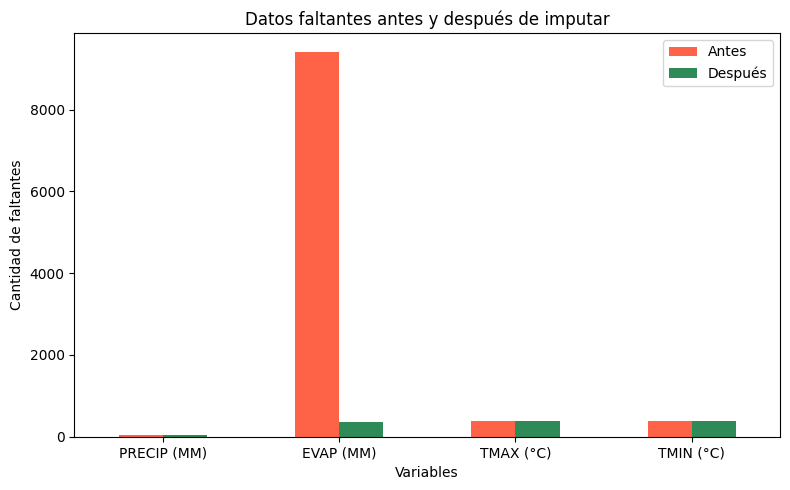

In [ ]:
cols = ["PRECIP (MM)", "EVAP (MM)", "TMAX (°C)", "TMIN (°C)"]
antes = datos_modelo[cols].isna().sum()
despues = resultado[cols].isna().sum()
comparacion = pd.DataFrame({"Antes": antes,"Después": despues})

ax = comparacion.plot(kind="bar", figsize=(8,5), color=["tomato", "seagreen"])
plt.title("Datos faltantes antes y después de imputar")
plt.xlabel("Variables")
plt.ylabel("Cantidad de faltantes")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

**Mediante el grafico se puede observar que se imputo una gran cantidad de datos, notable sobre todo en EVAP**